# Random Forest

## Overview

Random forest builds many decision trees on bootstrap samples of the data, using a random subset of features at each split. Predictions are aggregated by majority vote (classification) or mean (regression).

**Why it works:** Each tree overfits differently. Averaging across uncorrelated trees reduces variance while keeping bias low.

**Key hyperparameters:**

| Parameter | Effect | Typical range |
|---|---|---|
| `n_estimators` | Number of trees | 200–1000 |
| `max_features` | Features per split (`sqrt` for classification) | `sqrt`, `log2`, or float |
| `max_depth` | Depth of each tree | None (full) or 10–20 |
| `min_samples_leaf` | Min leaf size | 1–10 |

OOB (out-of-bag) error is a free cross-validation estimate — each tree is evaluated on samples not in its bootstrap.

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, roc_auc_score, RocCurveDisplay
from sklearn.inspection import permutation_importance
from scipy.special import expit

rng = np.random.default_rng(42)
n = 400
elevation  = rng.uniform(50, 400, n)
nitrate    = rng.gamma(2, 2, n)
phosphorus = rng.gamma(1.5, 1.5, n)
ph         = rng.normal(7.2, 0.5, n)
log_odds   = -2 + 0.004*elevation - 0.2*nitrate + 0.3*ph
label = (expit(log_odds) > 0.5).astype(int)
X = np.column_stack([elevation, nitrate, phosphorus, ph])
feat_names = ["elevation","nitrate","phosphorus","ph"]
X_tr, X_te, y_tr, y_te = train_test_split(X, label, test_size=0.25,
                                            stratify=label, random_state=42)
print(f"Train: {X_tr.shape}, Test: {X_te.shape}, Prevalence: {label.mean():.3f}")

Train: (300, 4), Test: (100, 4), Prevalence: 0.705


---
## Fitting and OOB Evaluation

In [2]:
rf = RandomForestClassifier(n_estimators=500, max_features="sqrt",
                             oob_score=True, random_state=42, n_jobs=-1)
rf.fit(X_tr, y_tr)
print(f"OOB accuracy:  {rf.oob_score_:.3f}")
print(f"Test accuracy: {rf.score(X_te, y_te):.3f}")
print(f"Test AUC-ROC:  {roc_auc_score(y_te, rf.predict_proba(X_te)[:,1]):.3f}")
print(classification_report(y_te, rf.predict(X_te), target_names=["absent","present"]))

OOB accuracy:  0.943
Test accuracy: 0.950
Test AUC-ROC:  0.992
              precision    recall  f1-score   support

      absent       0.93      0.90      0.92        30
     present       0.96      0.97      0.96        70

    accuracy                           0.95       100
   macro avg       0.94      0.94      0.94       100
weighted avg       0.95      0.95      0.95       100



---
## OOB Error vs Number of Trees

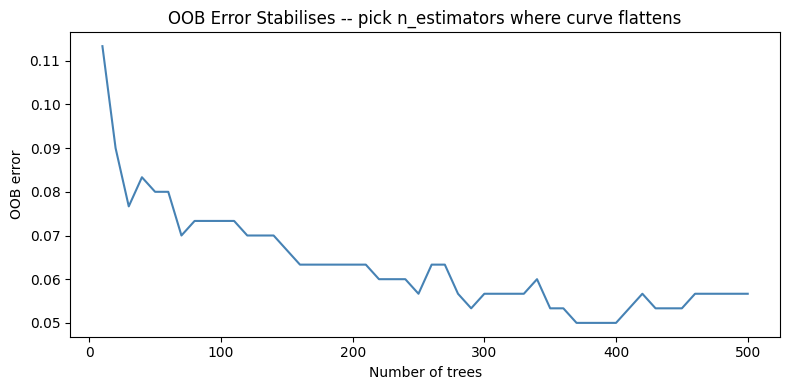

In [3]:
oob_errors = []
for n_trees in range(10, 501, 10):
    rf_n = RandomForestClassifier(n_estimators=n_trees, oob_score=True,
                                   random_state=42, n_jobs=-1)
    rf_n.fit(X_tr, y_tr)
    oob_errors.append(1 - rf_n.oob_score_)
plt.figure(figsize=(8,4))
plt.plot(range(10,501,10), oob_errors, color="steelblue", lw=1.5)
plt.xlabel("Number of trees"); plt.ylabel("OOB error")
plt.title("OOB Error Stabilises -- pick n_estimators where curve flattens")
plt.tight_layout(); plt.show()

---
## Feature Importance: Gini vs Permutation

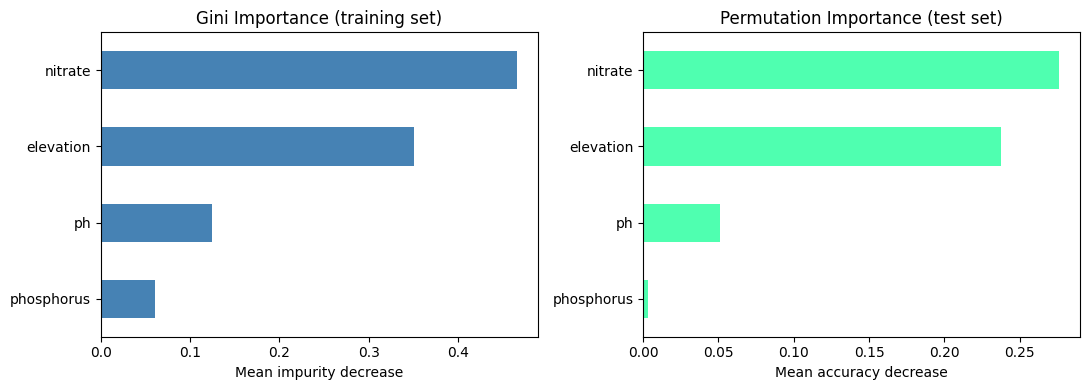

In [4]:
# Gini importance (training-set based, biased toward high-cardinality features)
gini_imp = pd.Series(rf.feature_importances_, index=feat_names)
# Permutation importance (test-set based, model-agnostic, unbiased)
perm = permutation_importance(rf, X_te, y_te, n_repeats=30, random_state=42, n_jobs=-1)
perm_imp = pd.Series(perm.importances_mean, index=feat_names)
fig, axes = plt.subplots(1,2,figsize=(11,4))
gini_imp.sort_values().plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title("Gini Importance (training set)")
axes[0].set_xlabel("Mean impurity decrease")
perm_imp.sort_values().plot(kind="barh", ax=axes[1], color="#4fffb0")
axes[1].set_title("Permutation Importance (test set)")
axes[1].set_xlabel("Mean accuracy decrease")
plt.tight_layout(); plt.show()

---
## ROC Curve

c:\Users\saman\Documents\Repos\python_methods_library\.venv\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


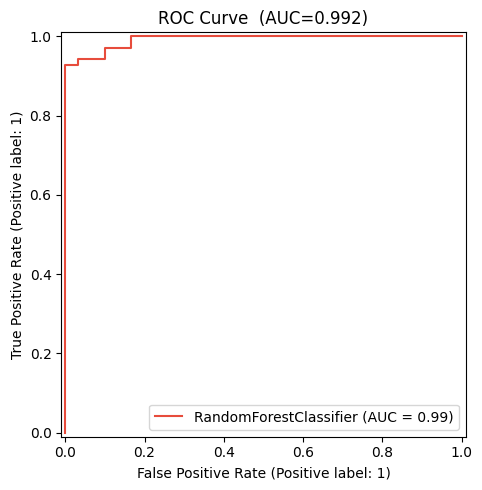

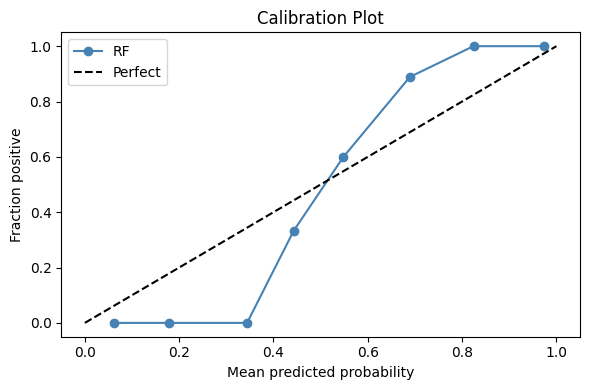

In [5]:
fig, ax = plt.subplots(figsize=(6,5))
RocCurveDisplay.from_estimator(rf, X_te, y_te, ax=ax, color="#e74c3c")
auc = roc_auc_score(y_te, rf.predict_proba(X_te)[:,1])
ax.set_title(f"ROC Curve  (AUC={auc:.3f})")
plt.tight_layout(); plt.show()
# Calibration check
from sklearn.calibration import calibration_curve
frac, mean_pred = calibration_curve(y_te, rf.predict_proba(X_te)[:,1], n_bins=8)
plt.figure(figsize=(6,4))
plt.plot(mean_pred, frac, "o-", color="steelblue", label="RF")
plt.plot([0,1],[0,1],"k--", label="Perfect")
plt.xlabel("Mean predicted probability"); plt.ylabel("Fraction positive")
plt.title("Calibration Plot"); plt.legend(); plt.tight_layout(); plt.show()

---

## Common Pitfalls

**1. Using Gini importance instead of permutation importance for feature ranking**  
Gini importance is computed on training data splits and is biased toward continuous and high-cardinality features. Permutation importance on the test set is model-agnostic and more reliable. Always use permutation importance when the feature ranking matters.

**2. Treating OOB score as equivalent to a proper held-out test**  
OOB provides a useful free estimate of generalisation but is optimistic for small forests and correlated features. Always reserve a separate test set and report test performance alongside OOB.

**3. Not calibrating predicted probabilities**  
Random forests produce poorly calibrated probabilities by default (often concentrated near 0 and 1). If predicted probabilities are used for decision-making, calibrate with `CalibratedClassifierCV` and check the calibration plot.

**4. Setting n_estimators too low**  
With too few trees, variance in the ensemble is high and OOB error is unstable. Plot OOB error vs n_estimators and choose a value where the curve has clearly flattened.

**5. Not accounting for class imbalance**  
Random forests fit each tree on a bootstrap sample which preserves class imbalance. Use `class_weight="balanced"` to weight the minority class, or use balanced bootstrap sampling (`max_samples` with stratification).

---
*python_methods_library - Samantha McGarrigle*